In [1]:
import requests
import zipfile
from pathlib import Path

In [2]:



data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"


if image_path.is_dir():
    print(f"{image_path} is already exsits!")
else:
    print(f"{image_path} creating...")
    image_path.mkdir(parents=True,exist_ok=True)
    
zip_file_path = data_path/"pizza_steak_sushi.zip"
#with open(zip_file_path,"wb") as f:
   # request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/data/pizza_steak_sushi.zip")
   # print(f"Downloading data")
    # f.write(request.content)

#unzip
#
#with zipfile.ZipFile(zip_file_path,"r") as zip_ref:
#    print("unziping")
#    zip_ref.extractall(image_path)

data\pizza_steak_sushi is already exsits!


In [3]:
import os
def walk_through_dir(dir_path):
    """ walks through dir_path returning its contents

    Args:
        dir_path (_type_): _description_
    """
    
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} dirs and {len(filenames)} images in {dirpath}")

In [4]:
walk_through_dir(image_path)

There are 2 dirs and 0 images in data\pizza_steak_sushi
There are 3 dirs and 0 images in data\pizza_steak_sushi\test
There are 0 dirs and 25 images in data\pizza_steak_sushi\test\pizza
There are 0 dirs and 19 images in data\pizza_steak_sushi\test\steak
There are 0 dirs and 31 images in data\pizza_steak_sushi\test\sushi
There are 3 dirs and 0 images in data\pizza_steak_sushi\train
There are 0 dirs and 78 images in data\pizza_steak_sushi\train\pizza
There are 0 dirs and 75 images in data\pizza_steak_sushi\train\steak
There are 0 dirs and 72 images in data\pizza_steak_sushi\train\sushi


In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"


data\pizza_steak_sushi\test\sushi\2394442.jpg sushi


torch.Size([408, 512, 3])

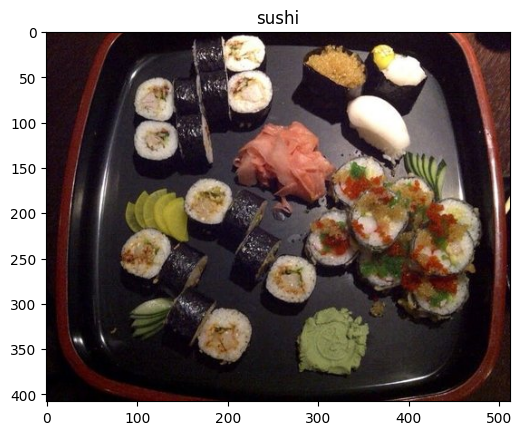

In [6]:
import random
from PIL import Image
from matplotlib import pyplot as plt
import torch
random.seed(42)

images_list = list(image_path.glob("**/*/*.jpg"))

random_image_path = random.choice(images_list)
random_image_class = random_image_path.parent.stem
print(random_image_path,random_image_class)


random_img = Image.open(random_image_path)

plt.imshow(random_img)
plt.title(random_image_class)
import numpy as np


t =torch.tensor(np.asarray(random_img))
t.shape

In [7]:
from torch.utils.data import DataLoader
from torchvision import datasets,transforms



In [8]:
data_transform = transforms.Compose([
    #Resize
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()    
])

In [9]:
def plot_transformed_images(image_paths,transform,n=2,seed=42):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path,"r") as f:
            fig,ax = plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Orignial/Size: {f.size}")
            ax[0].axis(False)
            
            
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed/Size: {transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Class : {image_path.parent.stem}")
            

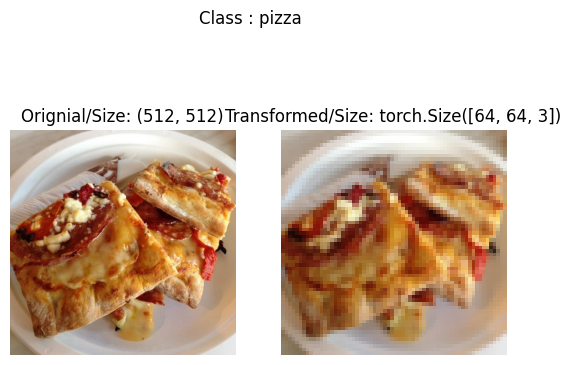

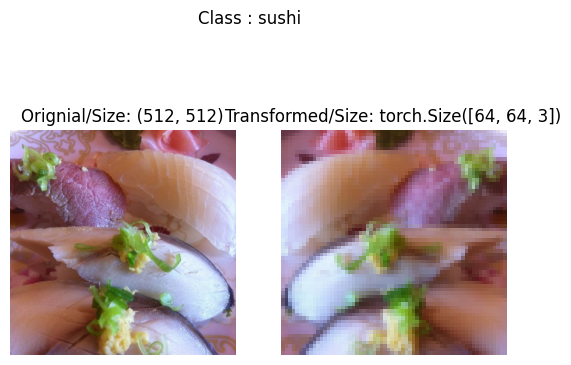

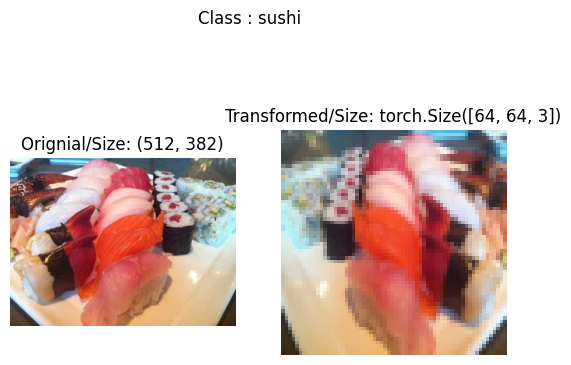

In [12]:
plot_transformed_images(images_list,data_transform,3,51)

In [11]:
TrainimgFolder = datasets.ImageFolder(train_dir,data_transform,target_transform=None)
TestimgFolder = datasets.ImageFolder(test_dir,data_transform,target_transform=None)


In [12]:
TrainimgFolder.classes

['pizza', 'steak', 'sushi']

image : torch.Size([3, 64, 64]) , label: pizza


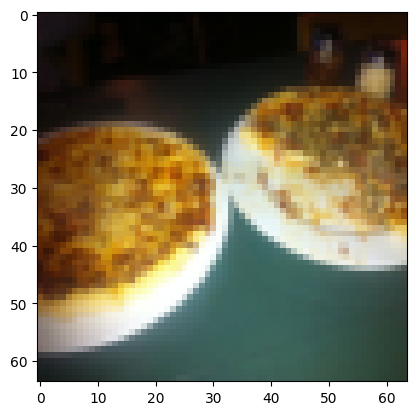

In [13]:
img ,label = TrainimgFolder[0][0],TrainimgFolder[0][1]


print(f"image : {img.shape} , label: {TrainimgFolder.classes[label]}")

plt.imshow(img.permute(1,2,0))

In [14]:
from torch.utils.data import DataLoader
import os
BATCH_SIZE=32
traindata_loader = DataLoader(dataset=TrainimgFolder,batch_size=BATCH_SIZE,num_workers=1,shuffle=True)
testdata_loader = DataLoader(dataset=TestimgFolder,batch_size=BATCH_SIZE,num_workers=1,shuffle=False)


traindata_loader,testdata_loader


(<torch.utils.data.dataloader.DataLoader at 0x1db890b9850>,
 <torch.utils.data.dataloader.DataLoader at 0x1db890b9e50>)

In [15]:
len(traindata_loader),len(testdata_loader)

(8, 3)

In [16]:
image,label = next(iter(traindata_loader))


image.shape,label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [17]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import dataset
from torchvision import transforms
from typing import Tuple,Dict,List



TrainimgFolder.classes


['pizza', 'steak', 'sushi']

In [18]:
target_dir = train_dir
target_dir 

WindowsPath('data/pizza_steak_sushi/train')

In [19]:
class_names_found = sorted([entry.name for entry in list(os.scandir(target_dir))])
class_names_found

['pizza', 'steak', 'sushi']

In [20]:
def find_classes(dir:str) -> Tuple[List[str],Dict[str,int]]:
    classes = sorted([entry.name for entry in list(os.scandir(dir)) if entry.is_dir()])
    if not classes:
        raise FileNotFoundError("There is no class in dir path")
    
    class_to_idx = {class_name:i for i,class_name in enumerate(classes)}
    
    return classes,class_to_idx

In [21]:
find_classes(target_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [22]:
import pathlib
from PIL import Image

class Food100L(torch.utils.data.Dataset):
    def  __init__(self
                  ,target_dir:str
                  ,transform=None):
        super().__init__()
        self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes,self.class_to_idx = find_classes(target_dir)
        
    def load_image(self,index:int) -> Image.Image:
        image_path = self.paths[index]
        return  Image.open(image_path)
    
    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index)  -> Tuple[torch.Tensor,int]:
        image= self.load_image(index)
        label=self.class_to_idx[self.paths[0].parent.name]
        return self.transform(image) if self.transform else image,label
    
    

In [34]:
Food100LDT =Food100L("data/pizza_steak_sushi/train",transform=data_transform)

In [33]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
    
    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples 
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

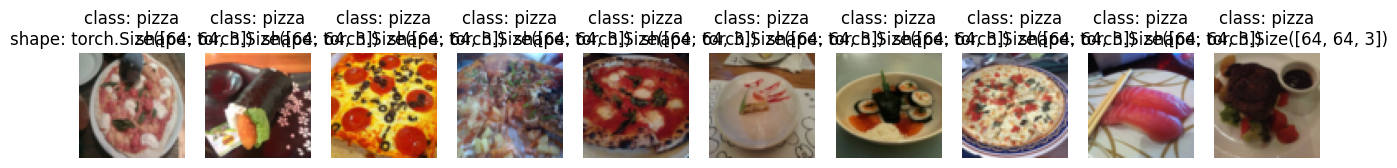

In [35]:
display_random_images(Food100LDT,Food100LDT.classes,10)